In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Load your brand new synthetic dataset
df = pd.read_csv('connected_healthcare_data.csv')

# 2. Preprocessing the Inputs (X)
# Machine Learning models only read numbers, so we convert 'Admission Type' into binary columns (1s and 0s)
# drop_first=True prevents the "dummy variable trap" by dropping the baseline 'Elective' column
X = pd.get_dummies(df[['Age', 'Admission Type']], drop_first=True)

# 3. Define the MULTIPLE Targets (Y)
# This is the "Multivariate" magic: we pass a list of TWO target columns!
y = df[['Length of Stay', 'Billing Amount']]

# 4. Train/Test Split
# We train the model on 80% of the data, and hide 20% to test it later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and Fit the Model
model = LinearRegression()
model.fit(X_train, y_train) # The model learns the relationships here

# 6. Make Predictions on the hidden 20%
# This outputs a 2D matrix of predictions (Column 1 = Predicted Stay, Column 2 = Predicted Bill)
predictions = model.predict(X_test)

# 7. Evaluate the Results
# multioutput='raw_values' tells it to give us a separate R-squared for each target
r2_scores = r2_score(y_test, predictions, multioutput='raw_values')

print("MULTIVARIATE REGRESSION RESULTS")
print("=" * 50)
print(f"R-squared for Length of Stay : {r2_scores[0]:.4f}")
print(f"R-squared for Billing Amount : {r2_scores[1]:.4f}")
print("=" * 50)

# 8. Let's look at the mathematical coefficients it learned!
print("\nThe model's learned coefficients (slopes):")
# We format this into a DataFrame so it's easy to read
coef_df = pd.DataFrame(
    model.coef_, 
    columns=X.columns, 
    index=['Predicting Length of Stay', 'Predicting Billing Amount']
)
print(coef_df)

MULTIVARIATE REGRESSION RESULTS
R-squared for Length of Stay : 0.8821
R-squared for Billing Amount : 0.9636

The model's learned coefficients (slopes):
                                 Age  Admission Type_Emergency  \
Predicting Length of Stay   0.049949                  5.019476   
Predicting Billing Amount  75.176875              17510.019507   

                           Admission Type_Urgent  
Predicting Length of Stay               2.027010  
Predicting Billing Amount            6030.034147  


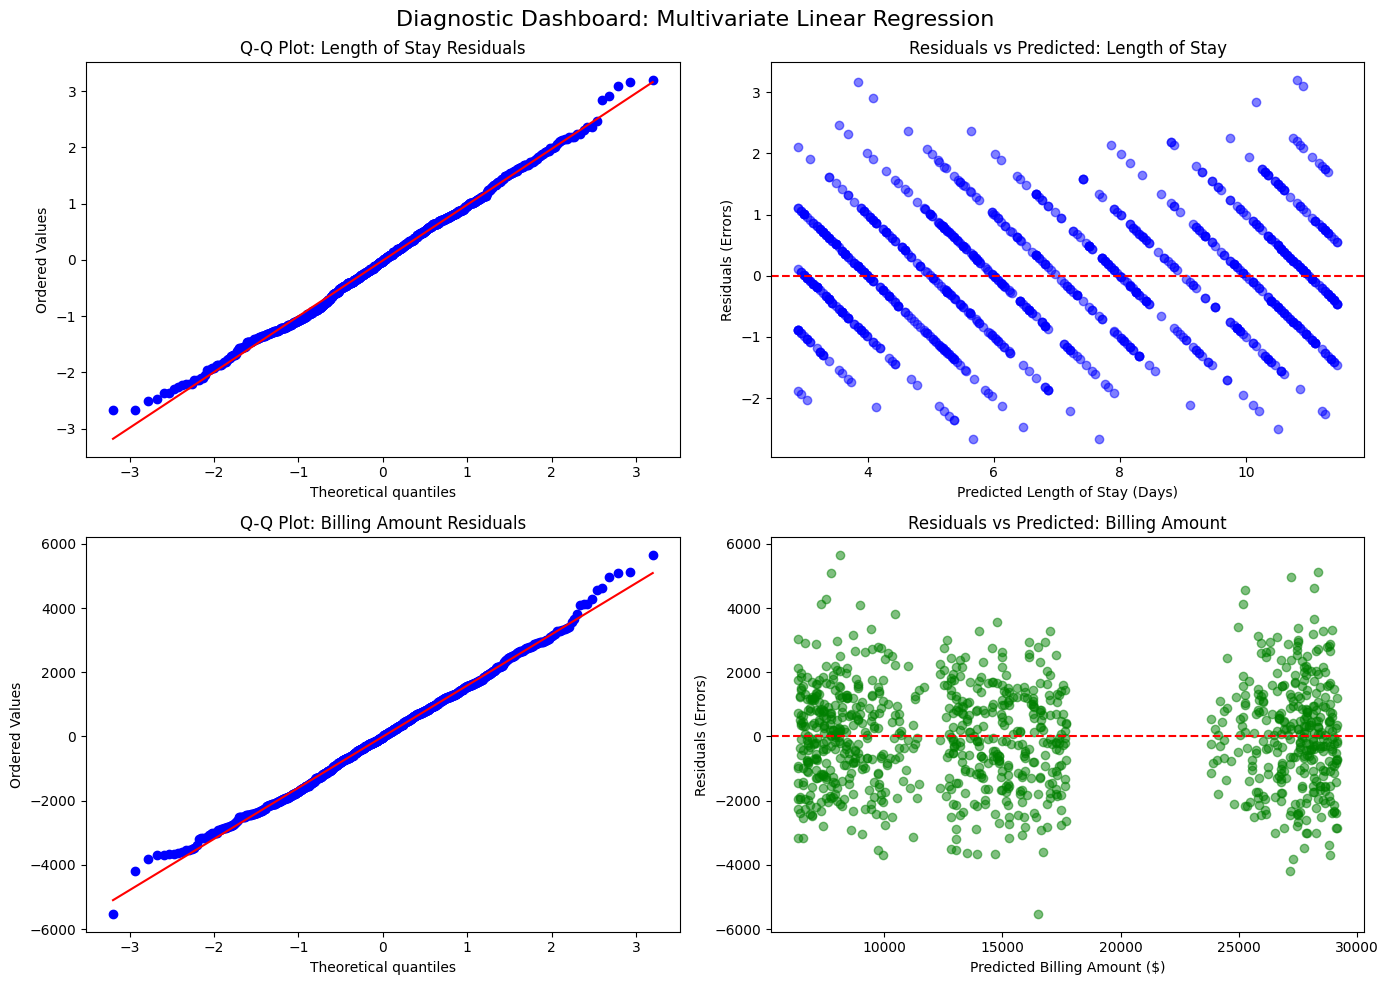

In [2]:
#Model adequacy tests. 

import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Calculate the Residuals (Errors)
# Actual values minus our Predicted values
residuals = y_test.values - predictions

# Separate the residuals and predictions for easy plotting
res_los = residuals[:, 0]       # Length of Stay errors
res_bill = residuals[:, 1]      # Billing Amount errors
pred_los = predictions[:, 0]    # Length of Stay predictions
pred_bill = predictions[:, 1]   # Billing Amount predictions

# 2. Set up a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diagnostic Dashboard: Multivariate Linear Regression', fontsize=16)

# --- ROW 1: LENGTH OF STAY DIAGNOSTICS ---

# Top Left: Q-Q Plot for Length of Stay (Normality)
stats.probplot(res_los, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Q-Q Plot: Length of Stay Residuals')

# Top Right: Residuals vs Predicted for Length of Stay (Homoscedasticity)
axes[0, 1].scatter(pred_los, res_los, alpha=0.5, color='blue')
axes[0, 1].axhline(y=0, color='red', linestyle='--') # The perfect prediction line
axes[0, 1].set_title('Residuals vs Predicted: Length of Stay')
axes[0, 1].set_xlabel('Predicted Length of Stay (Days)')
axes[0, 1].set_ylabel('Residuals (Errors)')

# --- ROW 2: BILLING AMOUNT DIAGNOSTICS ---

# Bottom Left: Q-Q Plot for Billing Amount (Normality)
stats.probplot(res_bill, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Billing Amount Residuals')

# Bottom Right: Residuals vs Predicted for Billing Amount (Homoscedasticity)
axes[1, 1].scatter(pred_bill, res_bill, alpha=0.5, color='green')
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_title('Residuals vs Predicted: Billing Amount')
axes[1, 1].set_xlabel('Predicted Billing Amount ($)')
axes[1, 1].set_ylabel('Residuals (Errors)')

plt.tight_layout()
plt.show()

In [ ]:
# The model passed both the Normality of errors test and the Homoskedasticity.

In [4]:
#Let's try for a different dataset

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load the dataset
df = pd.read_csv('AI_Impact_Student_Life_2026.csv')

# Inputs (X) and Outputs (Y)
X_raw = df[['Major', 'Primary_AI_Tool']]
y = df[['Time_Saved_Hours_Weekly', 'Career_Confidence_Score']]

# One-Hot Encoding for categorical variables
X = pd.get_dummies(X_raw, drop_first=True)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluate
r2_scores = r2_score(y_test, predictions, multioutput='raw_values')

print("R2 - Time_Saved_Hours_Weekly:", r2_scores[0])
print("R2 - Career_Confidence_Score:", r2_scores[1])

print("\nCoefficients:")
coef_df = pd.DataFrame(model.coef_, columns=X.columns, index=y.columns)
print(coef_df.to_string())

R2 - Time_Saved_Hours_Weekly: -0.02665898611035522
R2 - Career_Confidence_Score: -0.0029761024517525048

Coefficients:
                         Major_Business Administration  Major_Data Science  Major_Fine Arts  Major_Modern History  Major_Software Engineering  Primary_AI_Tool_Claude 3.5  Primary_AI_Tool_Gemini Pro  Primary_AI_Tool_GitHub Copilot  Primary_AI_Tool_Perplexity
Time_Saved_Hours_Weekly                       0.043672           -0.158678        -0.518352             -0.231831                   -0.331239                    0.210611                    0.328081                        0.388767                    0.731541
Career_Confidence_Score                       0.456423            0.652260         0.466557             -0.084413                    0.243410                    0.121604                   -0.313587                       -0.047279                    0.315473


In [ ]:
#Our model is telling us a fascinating real-world story:
#A student's Major and their AI Tool of choice have absolutely no mathematical correlation with how much time they save or how confident they feel about their careers.
#Let's try logistic regression.

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load the dataset
df = pd.read_csv('AI_Impact_Student_Life_2026.csv')

# 2. Create the Binary Target Variable (1 = High Concern, 0 = Medium/Low Concern)
df['High_Ethics_Concern'] = np.where(df['AI_Ethics_Concern'] == 'High', 1, 0)

# 3. Select our numerical inputs (X) and target (y)
X = df[['Age', 'GPA_Baseline', 'Time_Saved_Hours_Weekly']]
y = df['High_Ethics_Concern']

# 4. Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and Train the Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

# 6. Make Predictions
predictions = model.predict(X_test)

# 7. Evaluate the Results
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print("\nCONFUSION MATRIX:")
cm_df = pd.DataFrame(
    confusion_matrix(y_test, predictions),
    index=['Actual Not High (0)', 'Actual High (1)'],
    columns=['Predicted Not High (0)', 'Predicted High (1)']
)
print(cm_df)

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, predictions, zero_division=0))

LOGISTIC REGRESSION RESULTS

CONFUSION MATRIX:
                     Predicted Not High (0)  Predicted High (1)
Actual Not High (0)                     217                   0
Actual High (1)                          83                   0

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.72      1.00      0.84       217
           1       0.00      0.00      0.00        83

    accuracy                           0.72       300
   macro avg       0.36      0.50      0.42       300
weighted avg       0.52      0.72      0.61       300



In [ ]:
#The Right side of the confusion matrix is completely zero, this says no correlation at all between 'Age', 'GPA_Baseline', 'Time_Saved_Hours_Weekly' and 'High_Ethics_Concern'